# MRO - Orbit Determination Using TNF Doppler Observations

Copyright (c) 2010-2022, Delft University of Technology. All rights reserved. This file is part of the Tudat. Redistribution and use in source and binary forms, with or without modification, are permitted exclusively under the terms of the Modified BSD license.

## Overview

This notebook performs orbit determination (OD) for the Mars Reconnaissance Orbiter (MRO) using real Doppler tracking data from TNF files. The analysis processes multiple orbital arcs independently, estimating spacecraft state, dynamical model parameters, and empirical accelerations.

**Key Features:**
- **Multi-arc orbit determination**: Each arc spans approximately 3 days and is processed independently
- **Comprehensive force modeling**: Includes gravity field (120x120), atmospheric drag, solar radiation pressure, empirical accelerations, and third-body perturbations
- **Real observation data**: Uses compressed Doppler measurements from NASA's Deep Space Network (DSN)
- **Parameter estimation**: Estimates initial state, radiation pressure scaling, aerodynamic coefficients, and arc-wise empirical accelerations
- **Parallel processing**: Processes multiple arcs simultaneously using multiprocessing

**Analysis Workflow:**
1. Load SPICE kernels and TNF observation files for each arc
2. Set up dynamical environment with high-fidelity models
3. Process and filter Doppler observations
4. Define parameters to estimate (state, SRP scaling, drag/lift coefficients, empirical accelerations)
5. Perform orbit determination using weighted least squares estimation
6. Analyze prefit and postfit residuals and state differences from SPICE ephemeris

In [1]:
# Load required standard modules
import os
import pickle
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import multiprocessing
from matplotlib import pyplot as plt
import time as t

In [2]:
# Load required tudatpy modules
from tudatpy.util import redirect_std
from tudatpy.interface import spice
from tudatpy.astro import time_representation, element_conversion
from tudatpy.data import processTrk234

from tudatpy.dynamics import (
    environment_setup,
    propagation_setup,
    parameters_setup,
    propagation,
    parameters,
)
from tudatpy import estimation
from tudatpy.estimation import (
    estimation_analysis,
    observable_models_setup,
    observations,
    observations_setup,
)

from tudatpy.math import interpolators

# Import custom utility functions
from mro_utils import get_mro_files, macromodel_mro, get_rsw_state_difference

## Helper Function: Arc Processing

This function performs the complete orbit determination workflow for a single arc. It is designed to be called in parallel for multiple arcs.

**Input Arguments:**

The `inputs` variable is a list with eleven entries:
1. Arc index (integer identifier for this arc)
2. Start datetime of the arc
3. End datetime of the arc
4. List of TNF files to load
5. List of clock files to load
6. List of orientation kernels to load
7. List of tropospheric correction files to load
8. List of ionospheric correction files to load
9. List of MRO trajectory files to load
10. MRO reference frames definition file to load
11. MRO structure file to load

**Processing Steps:**

1. **Setup and File Loading**: Load all SPICE kernels, create output directories, and set up logging
2. **Observation Processing**: Load TNF data, filter to arc time bounds, compress Doppler observations, and compute initial residuals
3. **Environment Setup**: Create high-fidelity dynamical environment with detailed force models
4. **Antenna Reference Point**: Account for antenna position offset from center-of-mass
5. **Observation Model Configuration**: Define light-time corrections and observation simulators
6. **Propagation Settings**: Set up numerical integration and acceleration models
7. **Parameter Estimation Setup**: Define parameters to estimate including state, SRP scaling, drag/lift coefficients, and empirical accelerations
8. **Orbit Determination**: Perform weighted least squares estimation with a priori constraints
9. **Results Analysis**: Save residuals, state differences, and estimation outputs

**Outputs:**

For each arc, the function saves:
- `fitLog.txt`: Detailed log of the estimation process
- `estimationOutputDict.pkl`: Estimated parameters, formal errors, and nominal values
- `residDf.pkl`: DataFrame containing prefit, postfit, and SPICE residuals
- `rsw_state_difference_prefit.pkl`: State differences from SPICE before estimation (in RSW frame)
- `rsw_state_difference_postfit.pkl`: State differences from SPICE after estimation (in RSW frame)
- `arc_start_times.pkl`: Times defining empirical acceleration arc boundaries

In [3]:
def process_arc(inputs):
    """Process a single arc and save results"""

    # Unpack various input arguments
    arc_index = inputs[0]

    # Convert start and end datetime objects to Tudat Time variables. A time buffer of one day is subtracted/added to the start/end date
    # to ensure that the simulation environment covers the full time span of the loaded TNF files. This is mostly needed because some TNF
    # files - while typically assigned to a certain date - actually spans over (slightly) longer than one day. Without this time buffer,
    # some observation epochs might thus lie outside the time boundaries within which the dynamical environment is defined.
    startDateTime = inputs[1]
    endDateTime = inputs[2]

    # Retrieve lists of relevant kernels and input files to load (TNF files, clock and orientation kernels,
    # tropospheric and ionospheric corrections)
    tnf_files = inputs[3]
    clock_files = inputs[4]
    orientation_files = inputs[5]
    tro_files = inputs[6]
    ion_files = inputs[7]
    trajectory_files = inputs[8]
    frames_def_file = inputs[9]
    structure_file = inputs[10]

    # Create output folder for this specific arc
    arc_output_folder = f"{output_folder_base}/arc_{arc_index}/"
    if not os.path.exists(arc_output_folder):
        os.makedirs(arc_output_folder)

    # Create log file for this arc
    arc_log_file = arc_output_folder + f"fitLog.txt"
    with open(arc_log_file, "w") as f:
        f.write(f"Arc: {arc_index}\n")

    print(f"Processing arc {arc_index}: {startDateTime} to {endDateTime}")

    ### ------------------------------------------------------------------------------------------
    ### LOAD ALL REQUESTED KERNELS AND FILES
    ### ------------------------------------------------------------------------------------------

    spice.load_standard_kernels()

    # Load MRO orientation kernels (over the entire relevant time period).
    for orientation_file in orientation_files:
        spice.load_kernel(orientation_file)

    # Load MRO clock files
    for clock_file in clock_files:
        spice.load_kernel(clock_file)

    # Load MRO frame definition file (useful for HGA and spacecraft-fixed frames definition)
    spice.load_kernel(frames_def_file)

    # Load MRO trajectory kernels
    for trajectory_file in trajectory_files:
        spice.load_kernel(trajectory_file)

    # Load MRO spacecraft structure file (for antenna position in spacecraft-fixed frame)
    spice.load_kernel(structure_file)

    ### ------------------------------------------------------------------------------------------
    ### LOAD TNF OBSERVATIONS AND PERFORM PRE-PROCESSING STEPS
    ### ------------------------------------------------------------------------------------------

    # Remove first TNF file to avoid issues with time coverage at arc boundaries
    tnf_files = tnf_files[1:]

    # Special handling for arc 4: data is in the previous day TNF file
    if arc_index == 4:
        tnf_files.append("mro_kernels/mromagr2012_016_0520xmmmv1.tnf")

    # Load TNF observations, retaining only Doppler measurements
    tnfProcessor = processTrk234.Trk234Processor(
        tnf_files,
        ["doppler"],
        spacecraft_name="MRO",
    )
    original_observations = tnfProcessor.process()

    # Convert arc start/end times from UTC to TDB time scale (used internally by Tudat)
    arcStart = time_representation.DateTime.from_python_datetime(
        startDateTime
    ).to_epoch()
    arcEnd = time_representation.DateTime.from_python_datetime(endDateTime).to_epoch()

    time_scale_converter = time_representation.default_time_scale_converter()
    arcStart = time_scale_converter.convert_time_object(
        input_scale=time_representation.utc_scale,
        output_scale=time_representation.tdb_scale,
        input_value=time_representation.Time(arcStart),
    )
    arcEnd = time_scale_converter.convert_time_object(
        input_scale=time_representation.utc_scale,
        output_scale=time_representation.tdb_scale,
        input_value=time_representation.Time(arcEnd),
    )

    # Filter observations to retain only those within the arc time interval
    arc_filter = observations.observations_processing.observation_filter(
        observations.observations_processing.ObservationFilterType.time_bounds_filtering,
        arcStart.to_float(),
        arcEnd.to_float(),
        use_opposite_condition=True,
    )
    original_observations.filter_observations(arc_filter)
    original_observations.remove_empty_observation_sets()

    # Compress Doppler observations from 1.0 s integration time to 60.0 s
    # This reduces the number of observations while maintaining data quality
    compressed_observations = (
        observations_setup.observations_wrapper.create_compressed_doppler_collection(
            original_observations, 60, 10
        )
    )

    # Add transponder delay (time delay in spacecraft electronics)
    compressed_observations.set_transponder_delay("MRO", 1.4149e-6)

    # Determine observation and propagation time limits
    # Add 1-hour buffer to propagation times to ensure coverage of all observations
    observation_time_limits = original_observations.time_bounds_time_object
    obs_start_time = observation_time_limits[0]
    obs_end_time = observation_time_limits[1]

    prop_start_time = observation_time_limits[0] - 3600.0
    prop_end_time = observation_time_limits[1] + 3600.0

    ### ------------------------------------------------------------------------------------------
    ### CREATE DYNAMICAL ENVIRONMENT
    ### ------------------------------------------------------------------------------------------

    # Create default body settings for celestial bodies
    # These bodies will be used for gravitational perturbations
    bodies_to_create = [
        "Earth",
        "Sun",
        "Mercury",
        "Venus",
        "Mars",
        "Jupiter",
        "Saturn",
        "Phobos",
        "Deimos",
    ]
    global_frame_origin = "SSB"
    global_frame_orientation = "J2000"
    body_settings = environment_setup.get_default_body_settings_time_limited(
        bodies_to_create,
        prop_start_time.to_float(),
        prop_end_time.to_float(),
        global_frame_origin,
        global_frame_orientation,
    )

    # ====================
    # Earth Configuration
    # Modify default shape, rotation, and gravity field settings for the Earth
    body_settings.get("Earth").shape_settings = (
        environment_setup.shape.oblate_spherical_spice()
    )
    body_settings.get("Earth").rotation_model_settings = (
        environment_setup.rotation_model.gcrs_to_itrs(
            environment_setup.rotation_model.iau_2006,
            global_frame_orientation,
            interpolators.interpolator_generation_settings(
                interpolators.cubic_spline_interpolation(),
                prop_start_time.to_float(),
                prop_end_time.to_float(),
                3600.0,
            ),
            interpolators.interpolator_generation_settings(
                interpolators.cubic_spline_interpolation(),
                prop_start_time.to_float(),
                prop_end_time.to_float(),
                3600.0,
            ),
            interpolators.interpolator_generation_settings(
                interpolators.cubic_spline_interpolation(),
                prop_start_time.to_float(),
                prop_end_time.to_float(),
                60.0,
            ),
        )
    )
    body_settings.get("Earth").gravity_field_settings.associated_reference_frame = (
        "ITRS"
    )

    # Set up DSN ground stations
    body_settings.get("Earth").ground_station_settings = (
        environment_setup.ground_station.dsn_stations()
    )

    # ====================
    # Mars Configuration
    # Use high-accuracy rotation model and spherical harmonic gravity field (120x120)
    body_settings.get("Mars").rotation_model_settings = (
        environment_setup.rotation_model.mars_high_accuracy(
            base_frame=global_frame_orientation
        )
    )
    body_settings.get("Mars").gravity_field_settings = (
        environment_setup.gravity_field.predefined_spherical_harmonic(
            environment_setup.gravity_field.jgmro120d, 120
        )
    )
    body_settings.get("Mars").gravity_field_settings.associated_reference_frame = (
        "Mars_Fixed"
    )

    # Define gravity field variations for the tides on Mars
    # Models tidal effects from Sun and Phobos using Love number k2 = 0.1697
    body_settings.get("Mars").gravity_field_variation_settings = [
        environment_setup.gravity_field_variation.solid_body_tide("Sun", 0.1697, 2),
        environment_setup.gravity_field_variation.solid_body_tide("Phobos", 0.1697, 2),
    ]

    # Define Mars atmosphere settings using Mars-GRAM 2001
    body_settings.get("Mars").atmosphere_settings = (
        environment_setup.atmosphere.mars_dtm()
    )

    # Define Mars irradiance-based radiation pressure settings
    # Mars albedo and thermal emission contribute to radiation pressure on MRO
    luminosity_settings = (
        environment_setup.radiation_pressure.irradiance_based_constant_luminosity(
            250, 3.4e6
        )
    )
    body_settings.get("Mars").radiation_source_settings = (
        environment_setup.radiation_pressure.isotropic_radiation_source(
            luminosity_settings
        )
    )

    # ====================
    # MRO Spacecraft Configuration
    spacecraft_name = "MRO"
    spacecraft_central_body = "Mars"
    body_settings.add_empty_settings(spacecraft_name)

    # Retrieve translational ephemeris from SPICE (used as a priori for orbit determination)
    body_settings.get(spacecraft_name).ephemeris_settings = (
        environment_setup.ephemeris.interpolated_spice(
            prop_start_time.to_float(),
            prop_end_time.to_float(),
            10.0,
            spacecraft_central_body,
            global_frame_orientation,
        )
    )

    # Retrieve rotational ephemeris from SPICE
    body_settings.get(spacecraft_name).rotation_model_settings = (
        environment_setup.rotation_model.spice(
            global_frame_orientation, spacecraft_name + "_SPACECRAFT", ""
        )
    )

    # Set spacecraft mass (constant, from MRO mission specifications)
    body_settings.get(spacecraft_name).constant_mass = 1262.39  # [kg]
    
    # Set spacecraft shape using macromodel (detailed surface panel model)
    body_settings.get(spacecraft_name).vehicle_shape_settings = macromodel_mro()

    # Create environment
    bodies = environment_setup.create_system_of_bodies(body_settings)

    # Set MRO aerodynamics settings using spacecraft macromodel
    # Variable cross-section accounts for attitude-dependent drag area
    drag_coefficient = 2.0  # from Mazarico et al.
    lift_coefficient = 0.01  # small non-zero value to allow estimation
    ssh = 0  # surface-to-surface shadowing calculations disabled for speed
    aero_coefficient_settings = (
        environment_setup.aerodynamic_coefficients.constant_variable_cross_section(
            [drag_coefficient, 0, lift_coefficient], ssh
        )
    )
    environment_setup.add_aerodynamic_coefficient_interface(
        bodies, spacecraft_name, aero_coefficient_settings
    )

    # Set MRO radiation pressure settings using spacecraft macromodel
    # Paneled model accounts for detailed surface geometry and optical properties
    ssh = 100  # surface-to-surface shadowing grid resolution
    occulting_bodies_dict = dict(Sun=["Mars"])
    pixel_source_dict = dict(Sun=ssh)
    radiation_pressure_settings = (
        environment_setup.radiation_pressure.panelled_radiation_target(
            occulting_bodies_dict, pixel_source_dict
        )
    )
    environment_setup.add_radiation_pressure_target_model(
        bodies, spacecraft_name, radiation_pressure_settings
    )

    # Set TNF information (ground station characteristics, media corrections) in bodies
    tnfProcessor.set_tnf_information_in_bodies(bodies)

    ### ------------------------------------------------------------------------------------------
    ### SET ANTENNA AS REFERENCE POINT FOR DOPPLER OBSERVATIONS
    ### ------------------------------------------------------------------------------------------

    # Define MRO center-of-mass (COM) position w.r.t. the origin of the MRO-fixed reference frame
    # This accounts for the offset between the spacecraft reference point and COM
    com_position = [-0.001235, -1.14978, -0.001288]
    antenna_position_history = dict()

    # Create tabulated history of antenna position relative to COM
    # This is necessary because Doppler measurements reference the antenna phase center, not COM
    for obs_times in compressed_observations.get_observation_times_objects():
        time = obs_times[0].to_float() - 3600.0
        while time <= obs_times[-1].to_float() + 3600.0:
            state = np.zeros((6, 1))

            # For each observation epoch, retrieve the antenna position (spice ID "-74214") w.r.t. the origin of the MRO-fixed frame (spice ID "-74000")
            state[:3, 0] = spice.get_body_cartesian_position_at_epoch(
                "-74214", "-74000", "MRO_SPACECRAFT", "none", time
            )

            # Translate the antenna position to account for the offset between the origin of the MRO-fixed frame and the COM
            state[:3, 0] = state[:3, 0] - com_position

            # Store antenna position w.r.t. COM in the MRO-fixed frame
            antenna_position_history[time] = state
            time += 60.0

    # Create tabulated ephemeris settings from antenna position history
    antenna_ephemeris_settings = environment_setup.ephemeris.tabulated(
        antenna_position_history, "-74000", "MRO_SPACECRAFT"
    )

    # Create tabulated ephemeris for the MRO antenna
    antenna_ephemeris = environment_setup.ephemeris.create_ephemeris(
        antenna_ephemeris_settings, "Antenna"
    )

    # Set the spacecraft's reference point position to that of the antenna (in the MRO-fixed frame)
    compressed_observations.set_reference_point(
        bodies,
        antenna_ephemeris,
        "Antenna",
        "MRO",
        observable_models_setup.links.LinkEndType.reflector1,
    )

    ### ------------------------------------------------------------------------------------------
    ### DEFINE OBSERVATION MODEL SETTINGS
    ### ------------------------------------------------------------------------------------------

    #  Create light-time corrections list
    # These corrections account for various effects on signal propagation
    light_time_correction_list = list()
    
    # Add second-order relativistic correction (primarily from Sun's gravitational field)
    light_time_correction_list.append(
        observable_models_setup.light_time_corrections.approximated_second_order_relativistic_light_time_correction(
            ["Sun"]
        )
    )

    # Add tropospheric correction (signal delay through Earth's neutral atmosphere)
    light_time_correction_list.append(
        observable_models_setup.light_time_corrections.dsn_tabulated_tropospheric_light_time_correction(
            tro_files
        )
    )

    # Add ionospheric correction (signal delay through Earth's ionized atmosphere)
    spacecraft_name_per_id = dict()
    spacecraft_name_per_id[74] = "MRO"
    light_time_correction_list.append(
        observable_models_setup.light_time_corrections.dsn_tabulated_ionospheric_light_time_correction(
            ion_files, spacecraft_name_per_id
        )
    )

    # Create observation model settings for the Doppler observables
    # This defines the link geometry and all applicable corrections
    doppler_link_ends = compressed_observations.link_definitions_per_observable[
        observable_models_setup.model_settings.dsn_n_way_averaged_doppler_type
    ]

    observation_model_settings = list()
    for current_link_definition in doppler_link_ends:
        observation_model_settings.append(
            observable_models_setup.model_settings.dsn_n_way_doppler_averaged(
                current_link_definition, light_time_correction_list
            )
        )

    # Create observation simulators (used to compute predicted observables)
    observation_simulators = observations_setup.observations_simulation_settings.create_observation_simulators(
        observation_model_settings, bodies
    )

    # Compute initial residuals (observations minus predicted values using SPICE ephemeris)
    observations.compute_residuals_and_dependent_variables(
        compressed_observations, observation_simulators, bodies
    )

    # Filter outliers based on residual magnitude
    # Observations with residuals > 0.1 Hz are likely corrupted and removed
    filter_settings = {
        observable_models_setup.model_settings.dsn_n_way_averaged_doppler_type: 0.1,
    }

    observation_filters = dict()
    for obs_type, threshold in filter_settings.items():
        parser = observations.observations_processing.observation_parser(obs_type)
        residual_filter = observations.observations_processing.observation_filter(
            observations.observations_processing.ObservationFilterType.residual_filtering,
            threshold,
        )
        observation_filters[parser] = residual_filter

    compressed_observations.filter_observations(observation_filters)
    linkEndsDict = compressed_observations.link_definition_ids

    # Create DataFrame to store residual information
    # This will be populated with SPICE, prefit, and postfit residuals
    all_residuals = []
    all_times = []
    all_type_ids = []
    all_link_ends = []

    # Loop through each observable type to get its data
    for obs_type, typeName in zip(filter_settings.keys(), ["doppler"]):
        parser = observations.observations_processing.observation_parser(obs_type)

        # Get residuals, times, and link ends for the current observable type
        residuals = compressed_observations.get_concatenated_residuals(parser)
        times = compressed_observations.get_concatenated_observation_times(parser)
        link_ends_ids = compressed_observations.get_concatenated_link_definition_ids(
            parser
        )
        link_ends = [
            linkEndsDict[linkId][
                observable_models_setup.links.LinkEndType.transmitter
            ].reference_point
            + " - "
            + linkEndsDict[linkId][
                observable_models_setup.links.LinkEndType.receiver
            ].reference_point
            for linkId in link_ends_ids
        ]

        # Create a list of type identifiers
        type_ids = [typeName] * len(residuals)

        # Append the data to the main lists
        all_residuals.extend(residuals)
        all_times.extend(times)
        all_link_ends.extend(link_ends)
        all_type_ids.extend(type_ids)

    # Create DataFrame with all residual data
    residDf = pd.DataFrame(
        {
            "spice": all_residuals,
            "time": all_times,
            "link_ends": all_link_ends,
            "msrType": all_type_ids,
        }
    )

    ### ------------------------------------------------------------------------------------------
    ### DEFINE PROPAGATION SETTINGS
    ### ------------------------------------------------------------------------------------------

    # Define list of accelerations acting on MRO
    # This comprehensive model includes all relevant perturbations
    accelerations_settings_spacecraft = dict(
        Sun=[
            propagation_setup.acceleration.point_mass_gravity(),  # Solar gravitational attraction
            propagation_setup.acceleration.radiation_pressure(  # Solar radiation pressure
                environment_setup.radiation_pressure.paneled_target
            ),
        ],
        Mars=[
            propagation_setup.acceleration.spherical_harmonic_gravity(120, 120),  # Mars gravity field
            propagation_setup.acceleration.aerodynamic(),  # Atmospheric drag
            propagation_setup.acceleration.radiation_pressure(  # Mars albedo and thermal emission
                environment_setup.radiation_pressure.paneled_target
            ),
            propagation_setup.acceleration.empirical(),  # Empirical accelerations (to be estimated)
        ],
        Jupiter=[propagation_setup.acceleration.point_mass_gravity()],  # Third-body perturbation
        Saturn=[propagation_setup.acceleration.point_mass_gravity()],  # Third-body perturbation
        Earth=[propagation_setup.acceleration.point_mass_gravity()],  # Third-body perturbation
        Phobos=[propagation_setup.acceleration.point_mass_gravity()],  # Third-body perturbation
        Deimos=[propagation_setup.acceleration.point_mass_gravity()],  # Third-body perturbation
    )

    # Create accelerations settings dictionary
    acceleration_settings = {spacecraft_name: accelerations_settings_spacecraft}

    # Create acceleration models from settings
    bodies_to_propagate = [spacecraft_name]
    central_bodies = [spacecraft_central_body]
    acceleration_models = propagation_setup.create_acceleration_models(
        bodies, acceleration_settings, bodies_to_propagate, central_bodies
    )

    # Define integrator settings
    # RKF78 is a high-order adaptive integrator suitable for precise orbit propagation
    integration_step = 30.0
    integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step_size(
        time_representation.Time(0, integration_step),
        propagation_setup.integrator.rkf_78,
    )

    # Retrieve initial state from SPICE (this will be refined during estimation)
    initial_state = propagation.get_state_of_bodies(
        bodies_to_propagate, central_bodies, bodies, prop_start_time
    )

    # Define propagator settings
    propagator_settings = propagation_setup.propagator.translational(
        central_bodies,
        acceleration_models,
        bodies_to_propagate,
        initial_state,
        prop_start_time,
        integrator_settings,
        propagation_setup.propagator.time_termination(obs_end_time.to_float()),
    )

    ### ------------------------------------------------------------------------------------------
    ### DEFINE SET OF PARAMETERS TO BE ESTIMATED
    ### ------------------------------------------------------------------------------------------

    # Define parameters to estimate
    # Start with the initial state (position and velocity at arc start)
    parameter_settings = parameters_setup.initial_states(propagator_settings, bodies)

    # Define list of additional parameters beyond initial state
    extra_parameters = []

    # Solar radiation pressure scaling parameter
    # Accounts for uncertainties in surface optical properties and solar flux
    extra_parameters = [
        parameters_setup.radiation_pressure_target_direction_scaling(
            spacecraft_name, "Sun"
        ),
    ]
    
    # Define arc start times for arc-wise empirical accelerations
    # Empirical accelerations are estimated separately for each orbital revolution
    # This accounts for unmodeled forces (e.g., imperfect gravity field, attitude errors)
    mars_gravitational_parameter = bodies.get("Mars").gravitational_parameter
    keplerian_state = element_conversion.cartesian_to_keplerian(
        initial_state, mars_gravitational_parameter
    )
    semi_major_axis = keplerian_state[0]
    orbital_period = (
        2.0 * np.pi * np.sqrt(semi_major_axis**3 / mars_gravitational_parameter)
    )

    # Create list of arc start times (one per orbit)
    arc_start_times = []
    current_arc_start_time = obs_start_time.to_float()
    while current_arc_start_time < obs_end_time.to_float():
        arc_start_times.append(current_arc_start_time)
        current_arc_start_time += orbital_period

    # Save arc start times for later analysis
    with open(arc_output_folder + f"arc_start_times.pkl", "wb") as f:
        pickle.dump(arc_start_times, f)

    # Define empirical acceleration components to estimate for each arc
    # RSW frame: R=radial, S=along-track, W=cross-track
    # Each component can have constant, sine, and cosine terms (Fourier series)
    acceleration_components_to_estimate = {
        parameters_setup.EmpiricalAccelerationComponents.along_track_empirical_acceleration_component: [
            parameters_setup.EmpiricalAccelerationFunctionalShapes.constant_empirical,
            parameters_setup.EmpiricalAccelerationFunctionalShapes.sine_empirical,
            parameters_setup.EmpiricalAccelerationFunctionalShapes.cosine_empirical,
        ],
        parameters_setup.EmpiricalAccelerationComponents.across_track_empirical_acceleration_component: [
            parameters_setup.EmpiricalAccelerationFunctionalShapes.constant_empirical,
            parameters_setup.EmpiricalAccelerationFunctionalShapes.sine_empirical,
            parameters_setup.EmpiricalAccelerationFunctionalShapes.cosine_empirical,
        ],
    }
    extra_parameters.append(
        parameters_setup.arcwise_empirical_accelerations(
            spacecraft_name,
            "Mars",
            acceleration_components_to_estimate,
            arc_start_times,
        )
    )

    # Add aerodynamic coefficient scaling parameters
    # These account for uncertainties in drag and lift coefficients
    extra_parameters.append(
        parameters_setup.drag_component_scaling(spacecraft_name),
    )
    extra_parameters.append(
        parameters_setup.lift_component_scaling(spacecraft_name),
    )

    # Add additional parameters settings
    parameter_settings += extra_parameters

    # Create set of parameters to estimate
    parameters_to_estimate = parameters_setup.create_parameter_set(
        parameter_settings, bodies, propagator_settings
    )

    nominal_parameters = parameters_to_estimate.parameter_vector

    # Define a priori uncertainties for each parameter
    # These are used to weight the parameters in the least squares estimation
    posSigma = [1e3] * 3  # Position: 1 km
    velSigma = [1e-1] * 3  # Velocity: 10 cm/s
    srpScaleSigma = [2]  # SRP scaling: factor of 2 uncertainty
    dragSigma = [2]  # Drag coefficient: factor of 2 uncertainty
    liftSigma = [2]  # Lift coefficient: factor of 2 uncertainty
    radialAcc = []  # No radial empirical accelerations
    alongAcc = [1e-6] * 3 * len(arc_start_times)  # Along-track: 1 µm/s²
    acrossAcc = [1e-6] * 3 * len(arc_start_times)  # Cross-track: 1 µm/s²
    all_sigmas = (
        posSigma
        + velSigma
        + srpScaleSigma
        + dragSigma
        + liftSigma
        + radialAcc
        + alongAcc
        + acrossAcc
    )

    # Create the a priori covariance matrix (diagonal) from the sigmas
    # Inverse covariance is used as weight matrix in least squares
    apriori_covariance = np.diag(1 / np.square(all_sigmas))

    ### ------------------------------------------------------------------------------------------
    ### DEFINE ESTIMATION SETTINGS AND PERFORM THE FIT
    ### ------------------------------------------------------------------------------------------

    # Create estimator object
    # This sets up the orbit determination problem with all models and settings
    estimator = estimation_analysis.Estimator(
        bodies, parameters_to_estimate, observation_model_settings, propagator_settings
    )

    # Define estimation settings
    # Convergence checker stops after 6 iterations or when RMS residual change < threshold
    estimation_input = estimation_analysis.EstimationInput(
        compressed_observations,
        inverse_apriori_covariance=apriori_covariance,
        convergence_checker=estimation_analysis.estimation_convergence_checker(6),
    )
    estimation_input.define_estimation_settings(
        reintegrate_equations_on_first_iteration=False,  # Use SPICE state as initial guess
        reintegrate_variational_equations=True,  # Recompute sensitivities each iteration
        print_output_to_terminal=True,  # Show progress
        save_state_history_per_iteration=True,  # Save orbit for each iteration
    )

    # Perform estimation
    # Output is redirected to log file for this arc
    with redirect_std(arc_log_file, True, True):
        print(f"Arc {arc_index} interval:")
        print(
            time_representation.DateTime.from_epoch(arcStart),
            time_representation.DateTime.from_epoch(arcEnd),
        )
        print(
            "Observation time bounds:",
            time_representation.DateTime.from_epoch(obs_start_time),
            " - ",
            time_representation.DateTime.from_epoch(obs_end_time),
        )

        print(f"Propagation time limits:")
        print(
            time_representation.DateTime.from_epoch(prop_start_time),
            time_representation.DateTime.from_epoch(prop_end_time),
        )
        parameters.print_parameter_names(parameters_to_estimate)
        print(
            "Number of parameters to estimate:",
            len(nominal_parameters),
        )
        print("Nominal values +- apriori:")
        for value, sigma in zip(nominal_parameters, all_sigmas):
            print(f"{value:.6e} +- {sigma:.6e}")
        print("\n")
        estimation_output = estimator.perform_estimation(estimation_input)
        print("\n")
        print("Corrected values +- uncertainty:")
        for value, sigma in zip(
            estimation_output.final_parameters, estimation_output.formal_errors
        ):
            print(f"{value:.6e} +- {sigma:.6e}")

    # Save estimation output dictionary
    outputDict = {}
    outputDict["nominal"] = nominal_parameters
    outputDict["correted"] = estimation_output.final_parameters
    outputDict["formal_errors"] = estimation_output.formal_errors

    with open(arc_output_folder + f"estimationOutputDict.pkl", "wb") as f:
        pickle.dump(outputDict, f)

    ### ------------------------------------------------------------------------------------------
    ### COLLECT AND SAVE RESULTS
    ### ------------------------------------------------------------------------------------------

    # Collect results
    bestIterIndex = estimation_output.best_iteration
    residDf["prefit"] = estimation_output.residual_history[:, 0]
    residDf["postfit"] = estimation_output.residual_history[:, bestIterIndex]
    residDf.to_pickle(arc_output_folder + f"residDf.pkl")

    # Compute state differences from SPICE ephemeris (prefit)
    prefit_state_history = estimation_output.simulation_results_per_iteration[
        0
    ].dynamics_results.state_history_float

    rsw_state_difference = get_rsw_state_difference(
        prefit_state_history,
        spacecraft_name,
        spacecraft_central_body,
        global_frame_orientation,
    )

    rsw_df = pd.DataFrame(
        rsw_state_difference, columns=["t", "R", "T", "N", "vR", "vT", "vN"]
    )
    rsw_df.to_pickle(arc_output_folder + f"rsw_state_difference_prefit.pkl")
    
    # Compute state differences from SPICE ephemeris (postfit)
    estimated_state_history = estimation_output.simulation_results_per_iteration[
        bestIterIndex
    ].dynamics_results.state_history_float

    rsw_state_difference = get_rsw_state_difference(
        estimated_state_history,
        spacecraft_name,
        spacecraft_central_body,
        global_frame_orientation,
    )

    rsw_df = pd.DataFrame(
        rsw_state_difference, columns=["t", "R", "T", "N", "vR", "vT", "vN"]
    )
    rsw_df.to_pickle(arc_output_folder + f"rsw_state_difference_postfit.pkl")

    print(f"Finished processing arc {arc_index}")

    return arc_index

## Main Execution

### Setup Configuration

Define the arcs to process and set up the output directory structure.

In [4]:
if __name__ == "__main__":
    exec_start_time = t.time()

    # Set up the output folder
    output_folder_base = "mro_outputs"
    if not os.path.exists(output_folder_base):
        os.makedirs(output_folder_base)

    # Define arcs to process
    # Each tuple contains (start_datetime, end_datetime) for one arc
    # Arcs are approximately 3 days long and span January 1-22, 2012
    arcs = [
        (
            datetime.fromisoformat("2012-01-01 03:18:01.965"),
            datetime.fromisoformat("2012-01-04 01:58:15.132"),
        ),
        (
            datetime.fromisoformat("2012-01-04 02:25:09.706"),
            datetime.fromisoformat("2012-01-07 02:55:23.122"),
        ),
        (
            datetime.fromisoformat("2012-01-07 03:23:14.407"),
            datetime.fromisoformat("2012-01-10 02:03:27.113"),
        ),
        (
            datetime.fromisoformat("2012-01-10 02:22:44.539"),
            datetime.fromisoformat("2012-01-13 02:52:58.104"),
        ),
        (
            datetime.fromisoformat("2012-01-13 03:15:38.112"),
            datetime.fromisoformat("2012-01-16 02:05:51.095"),
        ),
        (
            datetime.fromisoformat("2012-01-16 02:22:44.352"),
            datetime.fromisoformat("2012-01-19 02:52:57.085"),
        ),
        (
            datetime.fromisoformat("2012-01-19 03:17:17.831"),
            datetime.fromisoformat("2012-01-22 01:57:31.076"),
        ),
    ]

    # Set up multiprocessing pool
    num_processes = len(arcs)

### Prepare Input Data for Each Arc

Retrieve all necessary SPICE kernels and data files for each arc. Files are downloaded automatically if not found locally.

In [5]:
inputs = []
for i, arc in enumerate(arcs):

    startEpoch = arc[0]
    endEpoch = arc[1]
    # Add 1-day buffer to ensure file coverage
    startEpochWithBuffer = startEpoch - timedelta(days=1)
    endEpochWithBuffer = endEpoch + timedelta(days=1)

    print("Files for arc {}".format(i))
    # First retrieve the names of all the relevant kernels and data files necessary to cover the specified time interval
    (
        clock_files,
        orientation_files,
        tro_files,
        ion_files,
        tnf_files,
        trajectory_files,
        frames_def_file,
        structure_file,
    ) = get_mro_files("mro_kernels/", startEpochWithBuffer, endEpochWithBuffer)
    print("\n")

    # Construct a list of input arguments containing the arguments needed this specific parallel run.
    # These include the start and end dates, along with the names of all relevant kernels and data files that should be loaded
    inputs.append(
        [
            i,
            startEpoch,
            endEpoch,
            tnf_files,
            clock_files,
            orientation_files,
            tro_files,
            ion_files,
            trajectory_files,
            frames_def_file,
            structure_file,
        ]
    )

Files for arc 0
---------------------------------------------
Download MRO clock 
relevant clock files
mro_kernels/mro_sclkscet_00112_65536.tsc
---------------------------------------------
Download MRO orientation kernels
relevant orientation files
mro_kernels/mro_sc_psp_111227_120102.bc
mro_kernels/mro_sc_psp_120103_120109.bc
mro_kernels/mro_hga_psp_120103_120109.bc
mro_kernels/mro_hga_psp_111227_120102.bc
mro_kernels/mro_sa_psp_120103_120109.bc
mro_kernels/mro_sa_psp_111227_120102.bc
---------------------------------------------
Download MRO tropospheric corrections files
relevant tropospheric corrections files
mro_kernels/mromagr2012_001_2012_032.tro
mro_kernels/mromagr2011_335_2012_001.tro
---------------------------------------------
Download MRO ionospheric corrections files
relevant ionospheric corrections files
mro_kernels/mromagr2012_001_2012_032.ion
mro_kernels/mromagr2011_335_2012_001.ion
---------------------------------------------
Download MRO TNF files
nb existing files

### Run Parallel Orbit Determination

Process all arcs in parallel using multiprocessing. Each arc is processed independently on a separate CPU core.

**Processing Details:**
- Each arc takes approximately 10-30 minutes to process depending on hardware
- Results are saved automatically to `mro_outputs/arc_X/` directories
- Progress can be monitored through log files: `mro_outputs/arc_X/fitLog.txt`

In [6]:
# Process arcs in parallel using enumerate to get index
with multiprocessing.get_context("fork").Pool(num_processes) as pool:
    pool.map(process_arc, inputs)

Processing arc 0: 2012-01-01 03:18:01.965000 to 2012-01-04 01:58:15.132000Processing arc 1: 2012-01-04 02:25:09.706000 to 2012-01-07 02:55:23.122000Processing arc 3: 2012-01-10 02:22:44.539000 to 2012-01-13 02:52:58.104000Processing arc 5: 2012-01-16 02:22:44.352000 to 2012-01-19 02:52:57.085000Processing arc 2: 2012-01-07 03:23:14.407000 to 2012-01-10 02:03:27.113000Processing arc 6: 2012-01-19 03:17:17.831000 to 2012-01-22 01:57:31.076000Processing arc 4: 2012-01-13 03:15:38.112000 to 2012-01-16 02:05:51.095000








Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initial states) defined by a single variable will be stored before those represented by a list of variables. The parameter order will be different than those in your parameter settings. It is recommended that you check the parameter order by calling the print_parameter_names(Python)/printEstimatableParameterEntries(C++) function
Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initial states) defined by a single variable will be stored before those represented by a list of variables. The parameter order will be different than those in your parameter settings. It is recommended that you check the parameter order by calling the print_parameter_names(Python)/printEstimatableParameterEntries(C++) function
Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initi

Arc 0 interval:
2012-01-01 03:19:08.148901283740997 2012-01-04 01:59:21.315985918045044
Observation time bounds: 2012-01-01 23:59:54.683925867080688  -  2012-01-03 21:32:22.683982312679291
Propagation time limits:
2012-01-01 22:59:54.683925867080688 2012-01-03 22:32:22.683982312679291
Number of parameters to estimate: 159
Nominal values +- apriori:
-3.632079e+06 +- 1.000000e+03
1.445152e+05 +- 1.000000e+03
3.343499e+05 +- 1.000000e+03
-1.840645e+02 +- 1.000000e-01
1.607799e+03 +- 1.000000e-01
-3.026222e+03 +- 1.000000e-01
1.000000e+00 +- 2.000000e+00
1.000000e+00 +- 2.000000e+00
1.000000e+00 +- 2.000000e+00
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000e+00 +- 1.000000e-06
0.000000

## Results Analysis

### Load Combined Results

Aggregate results from all processed arcs for visualization and analysis.

In [7]:
# Get list of all arc directories
arcDirs = [
    os.path.join(output_folder_base, d)
    for d in os.listdir(output_folder_base)
    if os.path.isdir(os.path.join(output_folder_base, d))
]

# Initialize lists to store combined data
all_residuals = []
all_arc_times = []

# Load residuals from all arcs
for arc_dir in arcDirs:
    arc_index = os.path.basename(arc_dir).split("_")[-1]
    print(f"Processing residuals from {arc_dir}")

    try:
        # Load residuals
        residDf = pd.read_pickle(f"{arc_dir}/residDf.pkl")
        residDf["arc_index"] = arc_index  # Add identifier column
        all_residuals.append(residDf)

        # Load arc times
        arc_times = pickle.load(open(f"{arc_dir}/arc_start_times.pkl", "rb"))
        for time in arc_times:
            all_arc_times.append(time)
    except FileNotFoundError as e:
        print(f"Warning: Could not load data from {arc_dir}: {e}")

Processing residuals from mro_outputs/arc_0
Processing residuals from mro_outputs/arc_6
Processing residuals from mro_outputs/arc_1
Processing residuals from mro_outputs/arc_4
Processing residuals from mro_outputs/arc_3
Processing residuals from mro_outputs/arc_2
Processing residuals from mro_outputs/arc_5


### Plot 1: Doppler Residuals Over Time

This figure shows three panels comparing different residual types:

**Panel 1 - SPICE Residuals (w.r.t. SPK):**
- Difference between observed Doppler and predicted values using SPICE ephemeris
- Represents errors in the operational SPICE ephemeris
- Typical RMS: ~10-20 mHz

**Panel 2 - Prefit Residuals:**
- Difference between observations and predicted values using SPICE state as initial guess
- Shows residuals before orbit determination
- Should be similar to SPICE residuals

**Panel 3 - Postfit Residuals:**
- Difference between observations and predicted values using estimated state
- Shows residuals after orbit determination
- Typical RMS: ~1-5 mHz (significant improvement over prefit)

Lower postfit RMS indicates successful orbit determination with good fit to observations.

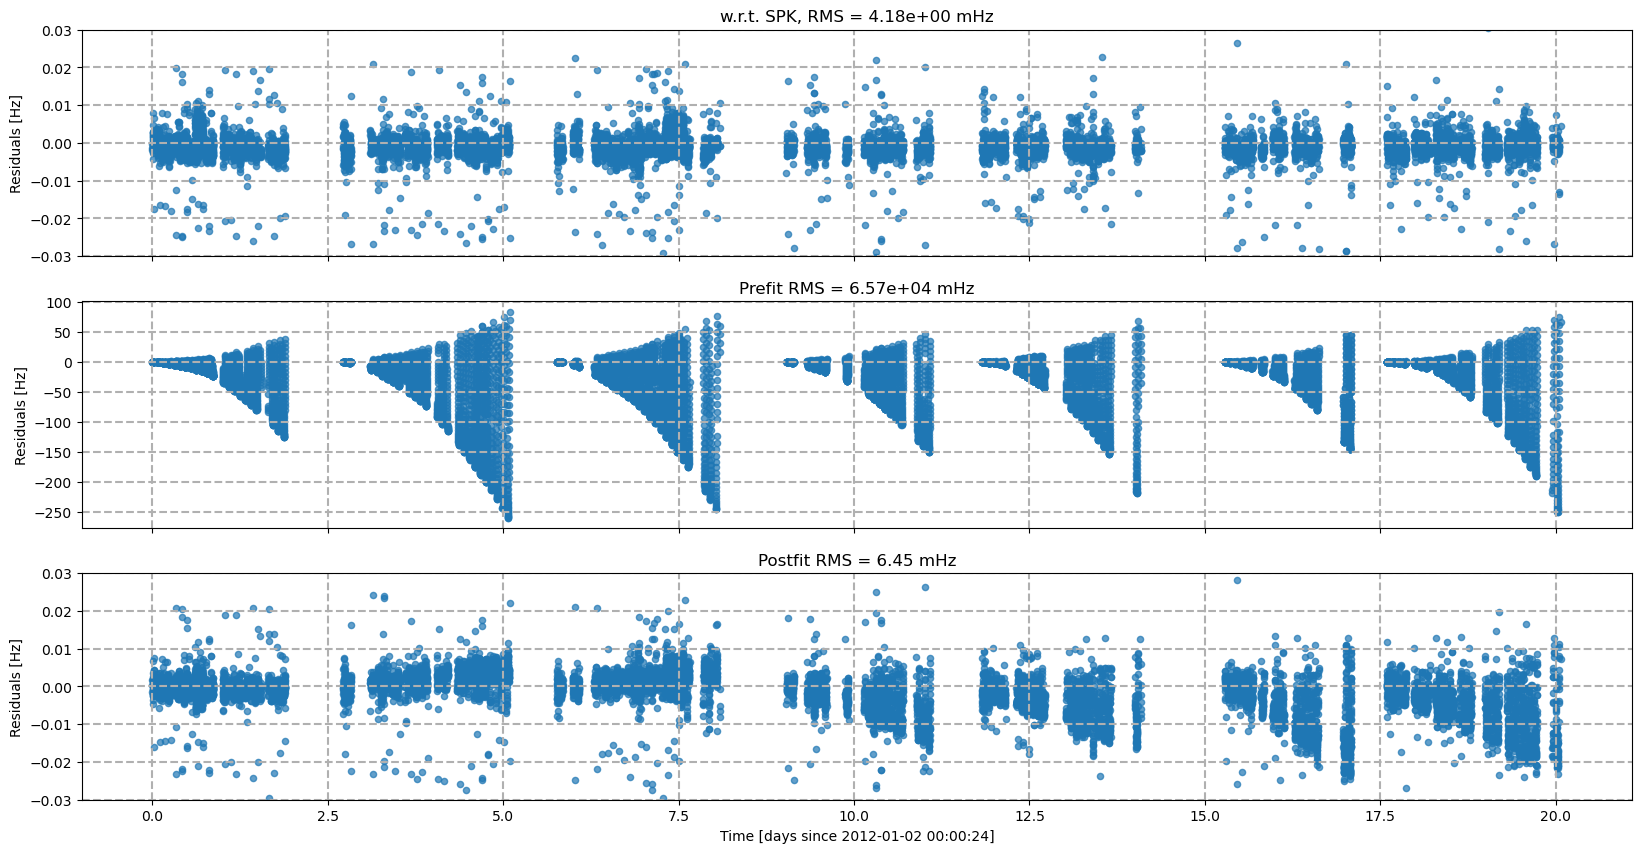

In [8]:
# Combine all residual dataframes
if all_residuals:
    combined_residDf = pd.concat(all_residuals, ignore_index=True)
    combined_residDf = combined_residDf.sort_values(by="time")
    all_arc_times = np.array(sorted(all_arc_times))

    # Calculate overall RMS values
    prefitRMS = np.sqrt(np.mean(np.square(combined_residDf["prefit"])))
    posfitRMS = np.sqrt(np.mean(np.square(combined_residDf["postfit"])))
    spiceRMS = np.sqrt(np.mean(np.square(combined_residDf["spice"])))

    # Plot residuals
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(20, 10))

    axes[0].set_title(f"w.r.t. SPK, RMS = {spiceRMS*1e3:.2e} mHz")
    axes[0].scatter(
        (combined_residDf["time"] - combined_residDf["time"].min()) / 86400,
        combined_residDf["spice"],
        s=20,
        marker="o",
        alpha=0.7,
    )

    axes[1].set_title(f"Prefit RMS = {prefitRMS*1e3:.2e} mHz")
    axes[1].scatter(
        (combined_residDf["time"] - combined_residDf["time"].min()) / 86400,
        combined_residDf["prefit"],
        s=20,
        marker="o",
        alpha=0.7,
    )

    axes[2].set_title(f"Postfit RMS = {(posfitRMS*1e3):.2f} mHz")
    axes[2].scatter(
        (combined_residDf["time"] - combined_residDf["time"].min()) / 86400,
        combined_residDf["postfit"],
        s=20,
        marker="o",
        alpha=0.7,
    )

    for ax in axes:
        ax.set_ylabel("Residuals [Hz]")
        ax.grid(which="both", linestyle="--", linewidth=1.5)

    axes[0].set_ylim([-0.03, 0.03])
    axes[2].set_ylim([-0.03, 0.03])

    date_time_obj = time_representation.DateTime.from_epoch(
        time_representation.Time(combined_residDf["time"].min())
    ).to_python_datetime()
    formatted_date = date_time_obj.strftime("%Y-%m-%d %H:%M:%S")
    axes[2].set_xlabel(f"Time [days since {formatted_date}]")

else:
    print("No residual data found!")

plt.show()

### Load State Difference Data

Collect prefit and postfit orbit differences from SPICE ephemeris for all arcs.

In [9]:
# Collect all state difference data
all_prefit_diff = []
all_postfit_diff = []

for arc_dir in arcDirs:
    arc_index = os.path.basename(arc_dir).split("_")[1]
    print(f"Processing state differences from {arc_dir}")

    # Only process first 5 arcs for clearer visualization
    if int(arc_index) > 4:
        continue

    try:
        # Load prefit state differences
        prefit_df = pd.read_pickle(f"{arc_dir}/rsw_state_difference_prefit.pkl")
        prefit_df["arc_index"] = arc_index
        all_prefit_diff.append((arc_index, prefit_df))

        # Load postfit state differences
        postfit_df = pd.read_pickle(f"{arc_dir}/rsw_state_difference_postfit.pkl")
        postfit_df["arc_index"] = arc_index
        all_postfit_diff.append((arc_index, postfit_df))
    except FileNotFoundError as e:
        print(f"Warning: Could not load state difference data from {arc_dir}: {e}")

Processing state differences from mro_outputs/arc_0
Processing state differences from mro_outputs/arc_6
Processing state differences from mro_outputs/arc_1
Processing state differences from mro_outputs/arc_4
Processing state differences from mro_outputs/arc_3
Processing state differences from mro_outputs/arc_2
Processing state differences from mro_outputs/arc_5


In [10]:
# Concatenate all postfit difference dataframes for RMS calculation
if all_postfit_diff:
    # Extract just the dataframes from the (arc_index, df) tuples
    all_postfit_dfs = [df for _, df in all_postfit_diff]

    # Concatenate into a single dataframe
    combined_postfit_df = pd.concat(all_postfit_dfs, ignore_index=True)

    # Calculate overall RMS for each component
    components = ["R", "T", "N"]
    overall_rms = {}

    for component in components:
        overall_rms[component] = np.sqrt(
            np.mean(np.square(combined_postfit_df[component]))
        )

### Plot 2: Orbit Differences from SPICE Ephemeris

This figure shows orbit differences in the RSW (Radial-Along track-Cross track) frame:

**Top Row - Prefit State Differences:**
- Shows orbit differences before orbit determination
- Each line represents a different arc (color-coded)
- Vertical gray lines separate arc boundaries
- Differences reflect errors in SPICE ephemeris

**Bottom Row - Postfit State Differences:**
- Shows orbit differences after orbit determination
- RMS values shown in subplot titles

**Interpretation:**
- Postfit differences represent orbit determination accuracy relative to SPICE
- Lower RMS indicates better agreement with SPICE ephemeris
- Discontinuities at arc boundaries are expected (independent arc processing)
- Overall RMS is computed across all arcs for each component

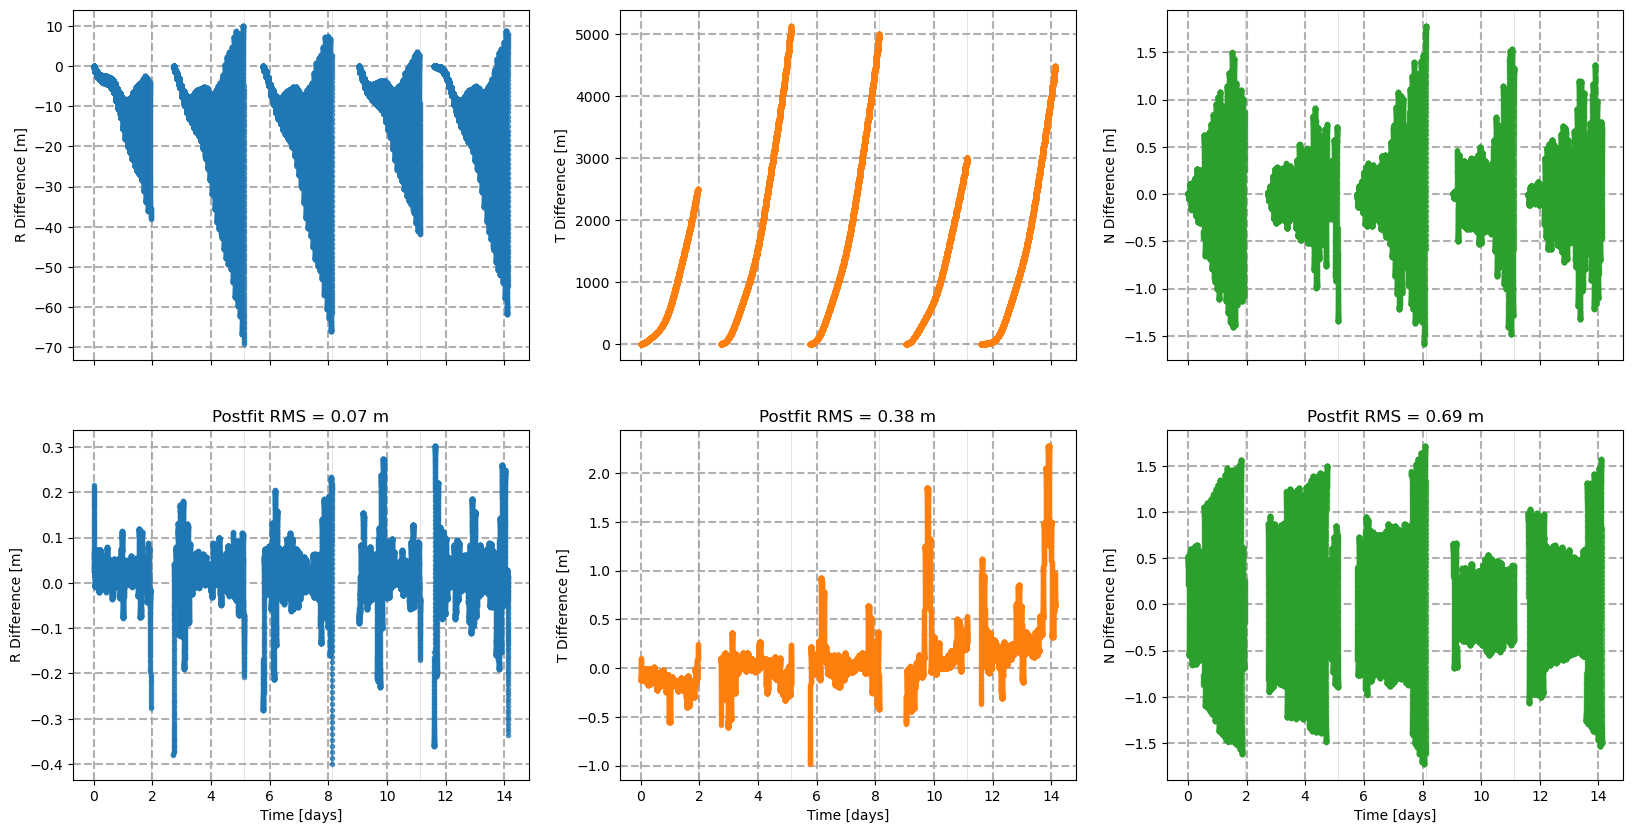

In [11]:
# Plot state differences by arc (no concatenation)
if all_prefit_diff and all_postfit_diff:
    # Sort by arc index
    all_prefit_diff.sort(key=lambda x: int(x[0]))
    all_postfit_diff.sort(key=lambda x: int(x[0]))

    # Find global min time for consistent x-axis
    global_t_min = min([df["t"].min() for _, df in all_prefit_diff])

    # Create figure with 2x3 grid (R,T,N components for prefit and postfit)
    fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True)

    # Components to plot
    components = ["R", "T", "N"]
    component_colors = {"R": "tab:blue", "T": "tab:orange", "N": "tab:green"}

    # Plot prefit state differences by arc (first row)
    for i, (arc_index, df) in enumerate(all_prefit_diff):
        # Get relative time in days
        time_days = (df["t"] - global_t_min) / 86400

        # Plot each component in its own panel
        for col, component in enumerate(components):
            axes[0, col].plot(
                time_days,
                df[component],
                "o-",
                label=f"Arc {arc_index}" if i == 0 else "",
                color=component_colors[component],
                alpha=0.7,
                markersize=3,
            )

            # Add light gray vertical lines to separate arcs
            if i < len(all_prefit_diff) - 1:
                arc_end = time_days.max()
                axes[0, col].axvline(
                    arc_end, color="gray", linestyle="-", linewidth=0.5, alpha=0.3
                )

    # Plot postfit state differences by arc (second row)
    for i, (arc_index, df) in enumerate(all_postfit_diff):
        # Get relative time in days
        time_days = (df["t"] - global_t_min) / 86400

        # Plot each component in its own panel
        for col, component in enumerate(components):
            axes[1, col].set_title(f"Postfit RMS = {overall_rms[component]:.2f} m")
            axes[1, col].plot(
                time_days,
                df[component],
                "o-",
                label=f"Arc {arc_index}" if i == 0 else "",
                color=component_colors[component],
                alpha=0.7,
                markersize=3,
            )

            # Add light gray vertical lines to separate arcs
            if i < len(all_postfit_diff) - 1:
                arc_end = time_days.max()
                axes[1, col].axvline(
                    arc_end, color="gray", linestyle="-", linewidth=0.5, alpha=0.3
                )

    # Set titles and labels
    for col, component in enumerate(components):
        # Add y-axis labels
        axes[0, col].set_ylabel(f"{component} Difference [m]")
        axes[1, col].set_ylabel(f"{component} Difference [m]")

        # Add grid to all subplots
        axes[0, col].grid(which="both", linestyle="--", linewidth=1.5)
        axes[1, col].grid(which="both", linestyle="--", linewidth=1.5)

    # Add x-axis labels to bottom row
    for col in range(3):
        axes[1, col].set_xlabel("Time [days]")

    plt.show()

## Summary

This notebook demonstrated multi-arc orbit determination for MRO using real DSN tracking data. Key results:

**Physical Parameters Estimated:**
- Initial state (position and velocity) for each arc
- Solar radiation pressure scaling (~0.8-1.2)
- Aerodynamic coefficients (drag and lift scaling)
- Arc-wise empirical accelerations (per orbit, in along-track and cross-track)

**Force Model Highlights:**
- Mars gravity: 120x120 spherical harmonic expansion
- Atmospheric drag: variable cross-section with macromodel
- Solar/Mars radiation pressure: paneled target model
- Third-body perturbations: Sun, Earth, Jupiter, Saturn, Phobos, Deimos
- Tidal effects: Mars solid body tides from Sun and Phobos

**Processing Notes:**
- Total processing time: ~1-3 hours for all arcs (parallel execution)
- Memory requirement: ~4-8 GB per arc
- Output files: ~50-100 MB per arc

For production orbit determination, consider:
- Extending arc length (5-7 days) for better parameter correlation handling
- Including range observations for improved radial accuracy
- Estimating Mars gravity field parameters for geodesy applications
- Using predicted attitude for more accurate radiation pressure modeling